In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier as rt
from sklearn.model_selection import train_test_split as ts
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer 
from sklearn.tree import DecisionTreeClassifier as dt

In [26]:
dataset=pd.read_csv("Titanic-Dataset.csv")

In [27]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
dataset.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)

In [31]:
num_cols = ["Age", "Fare"]
imputer = SimpleImputer(strategy='mean')
dataset[num_cols] = imputer.fit_transform(dataset[num_cols])


In [32]:
imputer = SimpleImputer(strategy='most_frequent') 
dataset[["Sex", "Embarked"]] = imputer.fit_transform(dataset[["Sex", "Embarked"]])

In [33]:

cat_cols = ["Sex", "Embarked"]
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(dataset[cat_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

# Drop original columns and join encoded
dataset.drop(columns=cat_cols, inplace=True)
dataset = pd.concat([dataset.reset_index(drop=True), encoded_df], axis=1)


In [34]:
features=dataset.drop(['Survived'], axis=1)
target=dataset['Survived']

In [35]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Age         891 non-null    float64
 2   SibSp       891 non-null    int64  
 3   Parch       891 non-null    int64  
 4   Fare        891 non-null    float64
 5   Sex_male    891 non-null    float64
 6   Embarked_Q  891 non-null    float64
 7   Embarked_S  891 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 55.8 KB


In [36]:
features.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [37]:
x_train,x_test,y_train,y_test=ts(features,target,test_size=0.2,random_state=1)

In [38]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [39]:
classifier = rt(n_estimators=10 ,criterion= 'entropy', random_state=0)
classifier.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [40]:
y_pred=classifier.predict(x_test)
print(np.concatenate((np.array(y_pred).reshape(-1, 1),np.array(y_test).reshape(-1, 1)), axis=1))

[[1 1]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [1 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [0 1]
 [0 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [0 1]
 [0 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [1 1]

In [41]:
cm= confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[86 20]
 [30 43]]


0.7206703910614525

In [42]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.81      0.77       106
           1       0.68      0.59      0.63        73

    accuracy                           0.72       179
   macro avg       0.71      0.70      0.70       179
weighted avg       0.72      0.72      0.72       179



In [43]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state=0)
classifier.fit(x_train, y_train)

SVC(kernel='linear', random_state=0)

In [44]:
y_pred_svm=classifier.predict(x_test)

In [45]:
cm= confusion_matrix(y_test,y_pred_svm)
print(cm)
accuracy_score(y_test,y_pred_svm)

[[90 16]
 [24 49]]


0.776536312849162

In [49]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(random_state=0)
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
cm= confusion_matrix(y_test,y_pred_lr)
print(cm)
accuracy_score(y_test,y_pred_lr)

[[89 17]
 [19 54]]


0.7988826815642458

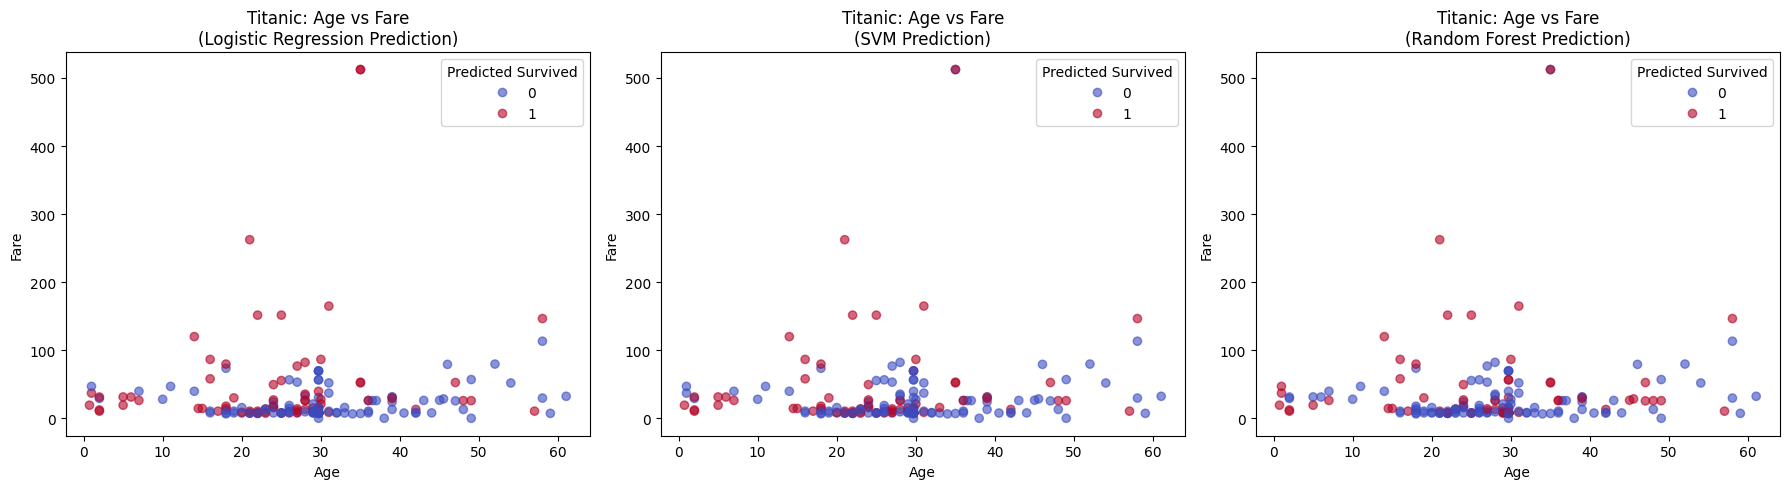

In [51]:
try:
    test_df = dataset.iloc[y_test.index].reset_index(drop=True)
except Exception:
    test_df = pd.DataFrame(x_test, columns=features.columns)
    test_df['Age'] = x_test[:, list(features.columns).index('Age')]
    test_df['Fare'] = x_test[:, list(features.columns).index('Fare')]

plots = []
if 'y_pred_lr' in locals():
    test_df['LogisticRegression'] = y_pred_lr
    plots.append(('Logistic Regression', 'LogisticRegression'))
if 'y_pred_svm' in locals():
    test_df['SVM'] = y_pred_svm
    plots.append(('SVM', 'SVM'))
if 'y_pred' in locals():
    test_df['RandomForest'] = y_pred
    plots.append(('Random Forest', 'RandomForest'))

plt.figure(figsize=(18,5))
for i, (title, col) in enumerate(plots):
    plt.subplot(1, len(plots), i+1)
    scatter = plt.scatter(test_df['Age'], test_df['Fare'], c=test_df[col], cmap='coolwarm', alpha=0.6)
    plt.xlabel('Age')
    plt.ylabel('Fare')
    plt.title(f'Titanic: Age vs Fare\n({title} Prediction)')
    plt.legend(*scatter.legend_elements(), title="Predicted Survived")
plt.tight_layout()
plt.show()